In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from pathlib import Path

In [ ]:
BASE_DIR = Path.cwd().parent.parent

MODEL_PATH = BASE_DIR / "models" / "final_model.keras"
IMG_SIZE = (224, 224)
CLASS_NAMES = ["dulled", "sharp", "used"]
N_TTA = 5

In [12]:
# Augmentation legere, identique a celle utilisee pour le TTA en evaluation
tta_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])


In [ ]:
def load_model():
    #Charge le modele entraine une seule fois
    print(f"Chargement du modele depuis {MODEL_PATH} ...")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Modele charge avec succes.")
    return model

In [ ]:
def preprocess_image(image_path):
    """
    Charge et pretraite une image exactement comme pendant l'entrainement.
    """
    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.expand_dims(image, axis=0)  # ajoute la dimension batch
    return image

In [15]:
def predict_tool_wear(model, image_path, use_tta=True):
    image = preprocess_image(image_path)

    if use_tta:
        preds_sum = model.predict(image, verbose=0)
        for _ in range(N_TTA):
            aug_image = tta_augmentation(image, training=True)
            preds_sum += model.predict(aug_image, verbose=0)
        probabilities = preds_sum / (N_TTA + 1)
    else:
        probabilities = model.predict(image, verbose=0)

    probabilities = probabilities[0]  # on enleve la dimension batch
    predicted_idx = np.argmax(probabilities)
    predicted_class = CLASS_NAMES[predicted_idx]
    confidence = float(probabilities[predicted_idx])

    result = {
        "predicted_class": predicted_class,
        "confidence": round(confidence, 4),
        "probabilities": {
            CLASS_NAMES[i]: round(float(probabilities[i]), 4)
            for i in range(len(CLASS_NAMES))
        }
    }

    return result

In [16]:
def predict_batch(model, image_paths, use_tta=True):
    """Predit l'usure pour une liste d'images."""
    results = []
    for image_path in image_paths:
        result = predict_tool_wear(model, image_path, use_tta=use_tta)
        result["image_path"] = str(image_path)
        results.append(result)
    return results

In [17]:
model = load_model()

Chargement du modele depuis c:\Users\hello2\Downloads\tool-wear-detection\models\final_model.keras ...
Modele charge avec succes.


In [18]:
test_image = BASE_DIR / "dataset" / "tool" / "T1R2B1.jpg"

print(test_image)
print(test_image.exists())

c:\Users\hello2\Downloads\tool-wear-detection\dataset\tool\T1R2B1.jpg
True


In [19]:
result = predict_tool_wear(
    model,
    test_image,
    use_tta=True
)

In [20]:
print("=== Résultat de la prédiction ===")

print(f"Image            : {test_image}")

print(f"Classe prédite   : {result['predicted_class']}")

print(f"Confiance        : {result['confidence']*100:.2f}%")

print("\nProbabilités détaillées :")

for classe, proba in result["probabilities"].items():
    print(f"{classe:8s} : {proba*100:.2f}%")

=== Résultat de la prédiction ===
Image            : c:\Users\hello2\Downloads\tool-wear-detection\dataset\tool\T1R2B1.jpg
Classe prédite   : sharp
Confiance        : 99.22%

Probabilités détaillées :
dulled   : 0.03%
sharp    : 99.22%
used     : 0.75%


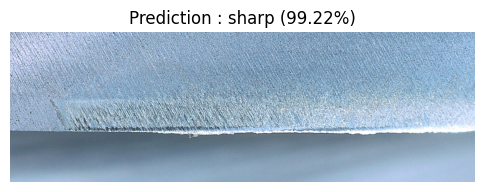

In [21]:
import matplotlib.pyplot as plt

image = plt.imread(test_image)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction : {result['predicted_class']} ({result['confidence']*100:.2f}%)"
)

plt.show()

In [22]:
test_images = [
    BASE_DIR / "dataset" / "tool" / "T1R2B1.jpg",
    BASE_DIR / "dataset" / "tool" / "T2R5B4.jpg",
    BASE_DIR / "dataset" / "tool" / "T3R8B2.jpg",
]

results = predict_batch(model, test_images)

for r in results:
    print("="*50)
    print("Image :", Path(r["image_path"]).name)
    print("Prediction :", r["predicted_class"])
    print("Confidence :", f"{r['confidence']*100:.2f}%")

Image : T1R2B1.jpg
Prediction : sharp
Confidence : 98.01%
Image : T2R5B4.jpg
Prediction : sharp
Confidence : 65.43%
Image : T3R8B2.jpg
Prediction : used
Confidence : 98.74%
